# Confusion Matrix

A **confusion matrix** is a table used to evaluate the performance of a classification model. It summarizes the outcomes of predictions by comparing them with the actual values.

The matrix is typically structured as a 2x2 table for binary classification, but can be extended to multi-class problems.

For binary classification, it consists of:

|                     | **Predicted Positive** | **Predicted Negative** |
| ------------------- | ---------------------- | ---------------------- |
| **Actual Positive** | True Positive (TP)     | False Negative (FN)    |
| **Actual Negative** | False Positive (FP)    | True Negative (TN)     |

### Definitions:

* **True Positive (TP):** Correctly predicted positive cases.
* **False Positive (FP):** Incorrectly predicted positive cases (actual is negative).
* **True Negative (TN):** Correctly predicted negative cases.
* **False Negative (FN):** Incorrectly predicted negative cases (actual is positive).

### Purpose:

The confusion matrix provides detailed insight into:

* Where the model is making correct and incorrect predictions.
* The types of errors (false positives vs. false negatives).

It can also be used as the basis for calculating other performance metrics such as:

* Accuracy = (TP + TN) / (TP + TN + FP + FN)
* Precision = TP / (TP + FP)
* Recall (Sensitivity) = TP / (TP + FN)
* F1 Score = 2 × (Precision × Recall) / (Precision + Recall)


In [2]:

import random
import pandas as pd
import numpy as np
from typing import List, Dict, Tuple, Any
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix

# Models
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression

# Dataviz
from matplotlib.colors import rgb2hex
import matplotlib.pyplot as plt
import plotly.graph_objects as go
import matplotlib
import seaborn as sns
import matplotlib.colors as mcolors



# Dataset and Modeling

Since this notebooks is focused primarily on the different ways a confusion matrix can be created, we will use a very simple classification dataset for illustration purposes only.

In [3]:

# --- Dataset Creation ---
n_features = 10
X, y = make_classification(n_samples=1000, n_features=n_features, n_informative=4, flip_y=0.2, weights=[0.8, 0.1],random_state=42)
y = y.reshape(-1, 1)
feature_names = [f'Feature {i+1}' for i in range(n_features)]
target_name = ['Target']
columns = feature_names + target_name
df = pd.DataFrame(np.concatenate([X, y], axis=1), columns=columns)

df_train, df_test = train_test_split(df, test_size=None, train_size=None, random_state=None, shuffle=True, stratify=None)
X_train_df, X_test_df = df_train[feature_names], df_test[feature_names]
y_train_df, y_test_df = df_train[target_name], df_test[target_name]


def augment_dataset_location_random(df, location_list, weights=None):
    if isinstance(weights, type(None)):
        df['Location'] = np.random.choice(location_list, size=len(df), p=weights)
        return df
    df['Location'] = np.random.choice(location_list, size=len(df))
    return df

# Location Augmentation
weights = [0.2, 0.25, 0.1, 0.15, 0.2, 0.1]
location_list = ['Chicago', 'New York', 'Boston', 'Miami', 'Los Angeles', 'Stanford']
df = augment_dataset_location_random(df, location_list, weights=weights)

df.head(5)


,Feature 1,Feature 2,Feature 3,Feature 4,Feature 5,Feature 6,Feature 7,Feature 8,Feature 9,Feature 10,Target,Location
0,0.818804,0.157958,-2.353074,-0.094482,-0.710792,1.599593,-0.377599,-0.904306,-0.732133,-0.911368,0.0,New York
1,-0.867835,0.506803,-0.458040,-0.362096,-1.560279,2.106314,-0.949249,-0.978681,0.480145,0.008818,0.0,Stanford
2,0.385657,0.131271,0.060150,-1.143280,-2.484931,2.462814,-2.021385,0.513573,-0.160158,0.591381,0.0,Stanford
3,-0.887346,1.359888,0.272575,-0.514486,-2.959916,5.183738,-2.218313,-1.820148,3.375495,0.554003,0.0,Los Angeles
4,-0.955486,0.369331,-1.062103,-0.028408,-1.472160,2.047420,-1.769926,-0.021427,-0.601396,0.103409,0.0,Chicago


In [4]:
lr = ExtraTreesClassifier()
lr.fit(X_train_df, y_train_df)

c:\Users\douglas.sgrott_indic\miniconda3\envs\tsfresh_venv\lib\site-packages\sklearn\base.py:1389: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


ExtraTreesClassifier()

# Confusion Matrix Implementation

In [8]:

# --- Factory ---
def create_confusion_matrix(dataset_dict, classifier=None, **kwargs):
    output_type = kwargs.pop('output_type', True)
    fmt_table = kwargs.pop('fmt_table', False)
    if output_type == 'image':
        max_cols = kwargs.pop('max_cols', 3)
        return plot_confusion_matrix(dataset_dict, max_cols)
    if output_type == 'plotly_table':
        return create_confusion_table_plotly(dataset_dict)
    if fmt_table:
        return create_fmt_confusion_table(dataset_dict)
    return create_confusion_table(dataset_dict)


# --- Pandas DataFrame ---
def create_confusion_table(dataset_dict, **kwargs):
    index = ['Actual Negative', 'Actual Positive']
    df_list = []

    for set_name in dataset_dict:
        y_ = dataset_dict[set_name]['y']
        y_pred = dataset_dict[set_name]['y_pred']

        cm = confusion_matrix(y_, y_pred)
        total = cm.sum()

        # Extract counts from the confusion matrix
        tn, fp, fn, tp = cm.ravel()

        # Format with percentages
        data = {
            'Predicted Negative': [f'{tn} ({tn/total:.2%})', f'{fn} ({fn/total:.2%})'],
            'Predicted Positive': [f'{fp} ({fp/total:.2%})', f'{tp} ({tp/total:.2%})'],
            'Dataset Label': [set_name, set_name],  # One row per actual class
        }

        df_list.append(pd.DataFrame(data, index=index))

    # Combine all datasets' tables
    df = pd.concat(df_list)
    return df


# --- Stylized HTML ---
def create_fmt_confusion_table(dataset_dict, **kwargs):
    # Define the index and columns
    index = ['Actual Negative', 'Actual Positive']
    columns = ['Predicted Negative', 'Predicted Positive']

    formatted_dfs = []
    # Iterate over each dataset in the dictionary
    for set_name, data in dataset_dict.items():
        y_ = data['y']
        y_pred = data['y_pred']

        # Compute the confusion matrix
        cm = confusion_matrix(y_, y_pred)
        total = cm.sum()

        # Create the DataFrame for the counts
        df_counts = pd.DataFrame(cm, index=index, columns=columns)
        df_aux_strings = pd.DataFrame([['True Negative<br>', 'False Positive<br>'], ['False Negative<br>', 'True Positive<br>']], index=index, columns=columns)

        # Create the DataFrame for the percentages
        df_percent = df_counts / total
        df_formatted = df_aux_strings + df_counts.astype(str) + ' (' + (df_percent * 100).round(2).astype(str) + '%)'

        # Add Dataset Label and reset the index
        df_formatted['Dataset Label'] = set_name
        df_formatted = df_formatted.reset_index().rename(columns={'index': 'Actual'})

        # Also create a percentage-only DataFrame for styling
        df_percent = df_percent.reset_index().rename(columns={'index': 'Actual'})

        # Append both formatted count & percentage DataFrames for styling
        formatted_dfs.append((df_formatted, df_percent, set_name))

    # Concatenate all formatted DataFrames (counts and percentages)
    combined_formatted = pd.concat([t[0] for t in formatted_dfs], ignore_index=True)
    combined_percent = pd.concat([t[1] for t in formatted_dfs], ignore_index=True)

    def style_per_row(row):
        # Get the set name for current row
        set_name = row['Dataset Label']
        cols = columns
        idx = row.name
        pct = combined_percent.loc[idx, cols]

        # Mask to get the subset of rows belonging to the current dataset
        dataset_mask = combined_formatted['Dataset Label'] == set_name
        dataset_percents = combined_percent.loc[dataset_mask, cols]
        vmin = dataset_percents.min().min()
        vmax = dataset_percents.max().max()

        # Normalize the values to apply a color gradient
        norm_values = pct * 0
        if vmax > vmin:
            norm_values = (pct - vmin) / (vmax - vmin)

        # Use a colormap for styling (Blues)
        cmap = matplotlib.colormaps['Blues']
        colors = [rgb2hex(cmap(v)) for v in norm_values]

        def hex_to_rgb(hex_color):
            hex_color = hex_color.lstrip('#')
            return tuple(int(hex_color[i:i+2], 16) for i in (0, 2, 4))

        def brightness(rgb):
            # Perceived brightness formula (YIQ)
            r, g, b = rgb
            return (r * 299 + g * 587 + b * 114) / 1000

        # Define the cell styling
        style = {}
        for col, color in zip(cols, colors):
            rgb = hex_to_rgb(color)
            bright = brightness(rgb)
            font_color = 'black' if bright > 128 else 'white'
            style[col] = f'background-color: {color}; color: {font_color}'

        # Reset the 'Dataset Label' and 'Actual' columns (no styling needed)
        style['Dataset Label'] = ''
        style['Actual'] = ''
        return pd.Series(style)

    # Apply the styling function to the combined DataFrame
    styled = combined_formatted.style.apply(style_per_row, axis=1)
    return styled

# --- Matplotlib Image ---
def plot_confusion_matrix(dataset_dict, max_cols=3, **kwargs):
    names = ['True Neg','False Pos','False Neg','True Pos']

    num_datasets = len(dataset_dict)
    num_rows = (num_datasets + max_cols - 1) // max_cols
    fig_width = 4*max_cols
    fig_height = 3*num_rows
    fig, axes = plt.subplots(nrows=num_rows, ncols=max_cols, figsize=(fig_width, fig_height), squeeze=False)
    axes = axes.flatten()

    for i, (name, data_dict) in enumerate(dataset_dict.items()):
        y = data_dict['y']
        y_pred = data_dict['y_pred']
        cm = confusion_matrix(y, y_pred)
        counts = [value for value in cm.flatten()]
        percentages = ['{0:.2%}'.format(value) for value in cm.flatten()/np.sum(cm)]
        labels = [f'{v1}\n{v2}\n{v3}' for v1, v2, v3 in zip(names, counts, percentages)]
        labels = np.asarray(labels).reshape(2,2)
        ax = axes[i]
        sns.heatmap(cm, annot=labels, cmap='Blues', fmt='', ax=ax)
        ax.set_title(name)
    
    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])
    plt.tight_layout()
    plt.close()
    return fig


# --- Plotly Table ---
def get_contrasting_font_color(hex_color):
    r, g, b = mcolors.to_rgb(hex_color)
    luminance = 0.299 * r + 0.587 * g + 0.114 * b
    return 'black' if luminance > 0.5 else 'white'


def create_confusion_table_plotly(dataset_dict, **kwargs):
    index = ['Actual Negative', 'Actual Positive']
    dataset_figures = []
    buttons = []

    for i, (set_name, data) in enumerate(dataset_dict.items()):
        y_ = data['y']
        y_pred = data['y_pred']
        conf_matrix = confusion_matrix(y_, y_pred)
        tn, fp, fn, tp = conf_matrix.ravel()
        total = conf_matrix.sum()

        pct_tn = tn / total
        pct_fp = fp / total
        pct_fn = fn / total
        pct_tp = tp / total

        # Table data
        df = pd.DataFrame([
            {
                'Dataset Label': set_name,
                'Actual': 'Actual Negative',
                'Predicted Negative': f'True Negative<br>{tn} ({pct_tn:.2%})',
                'Predicted Positive': f'False Positive<br>{fp} ({pct_fp:.2%})',
            },
            {
                'Dataset Label': set_name,
                'Actual': 'Actual Positive',
                'Predicted Negative': f'False Negative<br>{fn} ({pct_fn:.2%})',
                'Predicted Positive': f'True Positive<br>{tp} ({pct_tp:.2%})',
            },
        ])

        # Colors
        neg_percents = [pct_tn, pct_fn]
        pos_percents = [pct_fp, pct_tp]
        all_percents = np.array(neg_percents + pos_percents)
        norm = mcolors.Normalize(vmin=all_percents.min(), vmax=all_percents.max())
        cmap = matplotlib.colormaps['Blues']
        neg_colors = [mcolors.to_hex(cmap(norm(p))) for p in neg_percents]
        pos_colors = [mcolors.to_hex(cmap(norm(p))) for p in pos_percents]
        neg_font_colors = [get_contrasting_font_color(c) for c in neg_colors]
        pos_font_colors = [get_contrasting_font_color(c) for c in pos_colors]

        fill_colors = [
            ['white'] * 2,  # Dataset Label
            ['white'] * 2,  # Actual
            neg_colors,
            pos_colors,
        ]
        font_colors = [
            ['black'] * 2,  # Dataset Label
            ['black'] * 2,  # Actual
            neg_font_colors,
            pos_font_colors,
        ]

        table = go.Table(
            header=dict(
                values=["Dataset Label", "Actual", "Predicted Negative", "Predicted Positive"],
                fill_color='lightgrey',
                font=dict(color='black'),
                align='left'
            ),
            cells=dict(
                values=[
                    df['Dataset Label'],
                    df['Actual'],
                    df['Predicted Negative'],
                    df['Predicted Positive'],
                ],
                fill_color=fill_colors,
                font=dict(color=font_colors),
                align='left'
            ),
            visible=(i == 0)  # Only first visible initially
        )

        dataset_figures.append(table)

        # Dropdown button
        buttons.append(dict(
            label=set_name,
            method="update",
            args=[
                {"visible": [j == i for j in range(len(dataset_dict))]},
                {"title": f"Confusion Matrix<br>Dataset: {set_name}"}
            ]
        ))

    # Create figure with all table traces
    fig = go.Figure(data=dataset_figures)

    # Add dropdown to layout
    fig.update_layout(
        title=f"Confusion Matrix<br>Dataset: {list(dataset_dict.keys())[0]}",
        title_x=0.5,
        width=800,
        height=330,
        updatemenus=[{
            "buttons": buttons,
            "direction": "down",
            "showactive": True,
            "x": 0.0,
            "xanchor": "left",
            "y": 1.45,
            "yanchor": "top"
        }]
    )

    return fig


dataset_dict = {
    "Data":
    {
        "x": df[feature_names],
        "y": df[target_name],
        "y_pred": lr.predict(df[feature_names]),
        "y_prob": lr.predict_proba(df[feature_names]),
    }
}


## Confusion Matrix as a Pandas DataFrame

In [9]:
create_confusion_matrix(dataset_dict, fmt_table=False)

,Predicted Negative,Predicted Positive,Dataset Label
Actual Negative,786 (78.60%),0 (0.00%),Data
Actual Positive,32 (3.20%),182 (18.20%),Data


## Confusion Matrix as a stylized HTML table

In [10]:
create_confusion_matrix(dataset_dict, fmt_table=True)

,Actual,Predicted Negative,Predicted Positive,Dataset Label
0,Actual Negative,True Negative786 (78.6%),False Positive0 (0.0%),Data
1,Actual Positive,False Negative32 (3.2%),True Positive182 (18.2%),Data


## Confusion Matrix as a Matplotlib Image

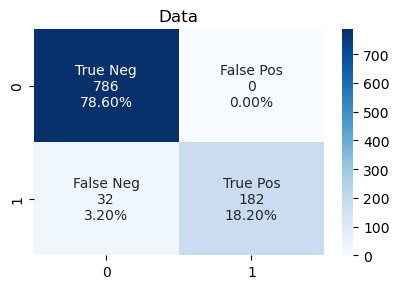

In [11]:

create_confusion_matrix(dataset_dict, max_cols=2, output_type='image')

## Confusion Matrix as a Plotly Table

In [12]:

create_confusion_matrix(dataset_dict, max_cols=2, output_type='plotly_table')


# Application: Analyzing data partitions

Here, we will simulate how this implementation can be used to analyze different data sets (Train/Test), clusters of data (as random samples) and categorical partitions of the data (using the Location column).

In [14]:

dataset_dict = {
    "Train":
    {
        "x": df_train[feature_names],
        "y": df_train[target_name],
        "y_pred": lr.predict(df_train[feature_names]),
        "y_prob": lr.predict_proba(df_train[feature_names]),
    },
    "Test":
    {
        "x": df_test[feature_names],
        "y": df_test[target_name],
        "y_pred": lr.predict(df_test[feature_names]),
        "y_prob": lr.predict_proba(df_test[feature_names]),
    },
}

create_confusion_matrix(dataset_dict, fmt_table=True)


,Actual,Predicted Negative,Predicted Positive,Dataset Label
0,Actual Negative,True Negative591 (78.8%),False Positive0 (0.0%),Train
1,Actual Positive,False Negative0 (0.0%),True Positive159 (21.2%),Train
2,Actual Negative,True Negative195 (78.0%),False Positive0 (0.0%),Test
3,Actual Positive,False Negative32 (12.8%),True Positive23 (9.2%),Test


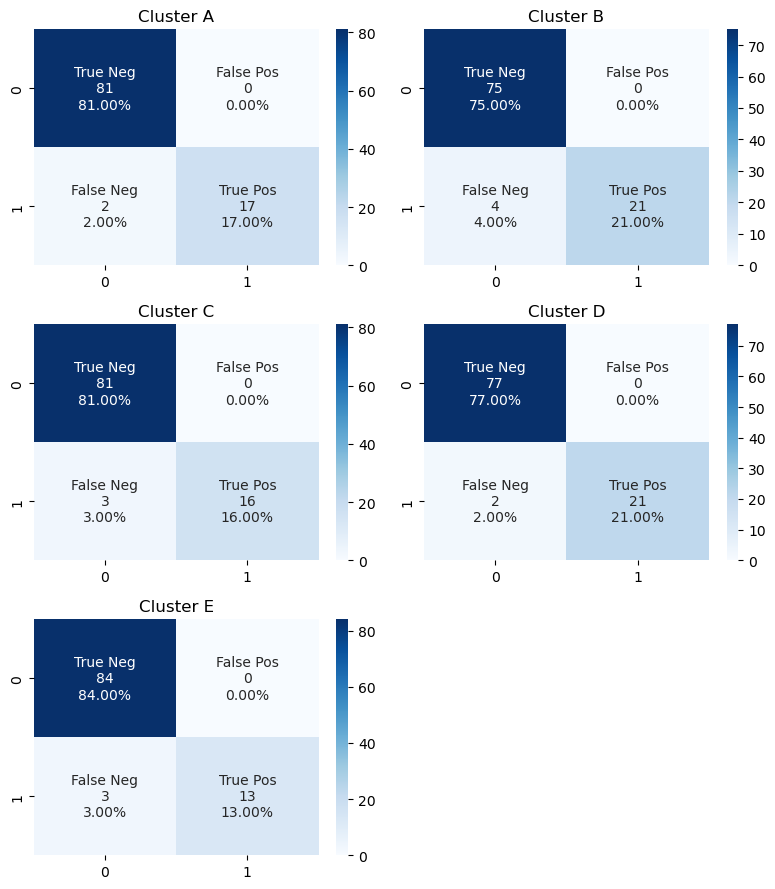

In [25]:

dataset_dict = {
    "Cluster A": {"y": df[target_name].sample(100, random_state=42), "y_pred": lr.predict(df[feature_names].sample(100, random_state=42))},
    "Cluster B": {"y": df[target_name].sample(100, random_state=43), "y_pred": lr.predict(df[feature_names].sample(100, random_state=43))},
    "Cluster C": {"y": df[target_name].sample(100, random_state=44), "y_pred": lr.predict(df[feature_names].sample(100, random_state=44))},
    "Cluster D": {"y": df[target_name].sample(100, random_state=45), "y_pred": lr.predict(df[feature_names].sample(100, random_state=45))},
    "Cluster E": {"y": df[target_name].sample(100, random_state=46), "y_pred": lr.predict(df[feature_names].sample(100, random_state=46))},
}

create_confusion_matrix(dataset_dict, output_type='image', max_cols=2)

In [23]:

dataset_dict = {
    location:
        {"y": df[df['Location'] == location][target_name],
         "y_pred": lr.predict(df[df['Location'] == location][feature_names]),}
        for location in df['Location'].unique()
}

create_confusion_matrix(dataset_dict, output_type='plotly_table')
